In [1]:
!ls ./drive/MyDrive/data/mnistdata/*.py

./drive/MyDrive/data/mnistdata/mnist.py


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from drive.MyDrive.data.mnistdata.mnist import load_mnist
from scipy.special import expit

$$
E = - \frac{1}{N} \sum_{n} \sum_{k} t_{nk} logy_{nk}
$$

t = [[2, 3, ...]]

t = [[0,0,1,0,0,0,0,0,0,0], [0,0,0,1,0,0,0,0,0,0], ...]

In [3]:
def cross_entropy_error(y, t):
    if y.ndim == 1: # 이미지 1장의 경우
        t = t.reshape(1, t.size) # (1, 10)
        y = y.reshape(1, y.size) # (1, 10)
    if t.size == y.size: # one-hot 인코딩이 되어 있는 경우
        t = t.argmax(axis=1) # t = [2, 3, 7, 8, 4, ...]
    batch_size = y.shape[0] # batch_size = 1, batch_size = 100
    return -np.sum(np.log(y[np.arange(batch_size), t])) / batch_size

y[np.arange(100), t]

In [4]:
y = np.array([
     [0.1, 0.05, 0.1, 0, 0.05, 0.1, 0, 0.6, 0.1, 0.2],
     [0.12, 0.48, 0.1, 0, 0.05, 0.1, 0, 0.2, 0, 0]
    ])

In [5]:
t = [7, 1]

In [6]:
y[np.arange(2), t]

array([0.6 , 0.48])

In [7]:
y[[0, 1], [7, 1]]

array([0.6 , 0.48])

In [8]:
y = np.arange(10).reshape(5, 2)

In [9]:
y_1d = y.reshape(-1)

# 1. 미니배치(mnist) 만들기

In [10]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

In [11]:
train_size = x_train.shape[0]

In [12]:
batch_size = 10

In [13]:
batch_mask = np.random.choice(train_size, batch_size)

In [14]:
batch_mask

array([23582, 21830, 10041, 40598, 53884, 49538, 38491, 32310, 37535,
       37669])

In [15]:
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]

In [16]:
x_batch

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [17]:
t_batch

array([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]])

# 2. 소프트맥스(softmax) 조정

In [18]:
def sigmoid(x):
    return expit(x)

def softmax(a):
    c = np.max(a)
    exp_a = np.exp(a - c) # 오버플로우 대책
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    return y

In [19]:
def predict(network, X):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    B1, B2, B3 = network['b1'], network['b2'], network['b3']

    A1 = np.dot(X, W1) + B1
    Z1 = sigmoid(A1)
    A2 = np.dot(Z1, W2) + B2
    Z2 = sigmoid(A2)
    A3 = np.dot(Z2, W3) + B3
    Y = softmax(A3)
    return Y

def init_network():
    with open('./drive/My Drive/data/mnistdata/sample_weight.pkl', 'rb') as f:
        network = pickle.load(f)
    return network

In [20]:
def get_data():
    (X_train, t_train), (X_test, t_test) = load_mnist(flatten=True, normalize=False)
    return X_test, t_test

In [21]:
x, t = get_data()

In [22]:
x.shape, t.shape

((10000, 784), (10000,))

In [23]:
network = init_network()

In [24]:
x.shape, network['W1'].shape, network['W2'].shape, network['W3'].shape

((10000, 784), (784, 50), (50, 100), (100, 10))

In [25]:
accuracy_cnt = 0
for i in range(len(x)):
    y = predict(network, x[i])
    p = np.argmax(y)
    if p == t[i]:
        accuracy_cnt += 1
print(accuracy_cnt / len(x))

0.9207


In [26]:
y = predict(network, x)

In [27]:
y.shape

(10000, 10)

In [28]:
y[1]

array([8.7074454e-09, 2.7697206e-08, 2.3823570e-05, 1.5606886e-07,
       2.2471885e-12, 1.7862394e-08, 1.2425485e-07, 6.4393625e-12,
       6.9177473e-09, 9.9881658e-14], dtype=float32)

In [29]:
np.sum(y[1])

np.float32(2.4165089e-05)

In [30]:
np.sum(y)

np.float32(1.0)

In [31]:
a_test = np.array([[1,2,3], [10, 5, 4]])

In [32]:
np,sum(softmax(a_test[1]))

(<module 'numpy' from '/usr/local/lib/python3.12/dist-packages/numpy/__init__.py'>,
 np.float64(1.0000000000000002))

In [33]:
softmax(a_test)

array([[1.22116897e-04, 3.31948142e-04, 9.02328603e-04],
       [9.89523466e-01, 6.66735667e-03, 2.45278345e-03]])

In [34]:
np.sum(softmax(a_test), axis=1)

array([0.00135639, 0.99864361])

In [35]:
# 소프트맥스 고치기 이미지 2장에 대해서
def softmax(a):
    c = np.max(a) # axis=1 추가
    exp_a = np.exp(a- c) # a.T 해서 shape 맞추기
    sum_exp_a = np.sum(exp_a) # axis=0 추가
    y = exp_a / sum_exp_a
    return y

In [36]:
a_test

array([[ 1,  2,  3],
       [10,  5,  4]])

In [37]:
c = np.max(a_test, axis=1)

In [38]:
c.shape

(2,)

In [39]:
c.T.shape

(2,)

In [40]:
a_test.T - c

array([[-2,  0],
       [-1, -5],
       [ 0, -6]])

In [41]:
# c를 shape를 바꾸면 T를 해도 안바뀜 그래서 (2,3)인 a_test의 shape를 바꿔보자
exp_a = np.exp(a_test.T - c)
exp_a

array([[0.13533528, 1.        ],
       [0.36787944, 0.00673795],
       [1.        , 0.00247875]])

In [42]:
sum_exp_a = np.sum(exp_a, axis=0)
sum_exp_a

array([1.50321472, 1.0092167 ])

In [43]:
y = exp_a / sum_exp_a
y

array([[0.09003057, 0.99086747],
       [0.24472847, 0.00667641],
       [0.66524096, 0.00245611]])

In [44]:
np.sum(y, axis=0)

array([1., 1.])

In [45]:
# 최종
def softmax(a):
    c = np.max(a, axis=1)
    exp_a = np.exp(a.T - c)
    sum_exp_a = np.sum(exp_a, axis=0)
    y = exp_a / sum_exp_a
    return y.T

In [46]:
softmax(a_test)

array([[0.09003057, 0.24472847, 0.66524096],
       [0.99086747, 0.00667641, 0.00245611]])

In [47]:
a_test[0]

array([1, 2, 3])

In [48]:
# 1장일 때
softmax(a_test[0]) # 2장일 때로 고쳤는데 1장은 안됨

AxisError: axis 1 is out of bounds for array of dimension 1

이런 경우 여러장일 때 먼저 맞추고 1장 들어갈 때는 따로 조건 걸어서 만들어 주자

In [49]:
def softmax(a):
    if a.ndim == 2:
        c = np.max(a, axis=1)
        exp_a = np.exp(a.T - c)
        sum_exp_a = np.sum(exp_a, axis=0)
        y = exp_a / sum_exp_a
        return y.T
    a = a - np.max(a)
    return np.exp(a) / np.sum(np.exp(a))

In [50]:
# 1차 2차 두개 다 들어가게끔
def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T
    x = x - np.max(x)
    return np.exp(x) / np.sum(np.exp(x))

In [51]:
# 2차원
softmax(a_test)

array([[0.09003057, 0.24472847, 0.66524096],
       [0.99086747, 0.00667641, 0.00245611]])

In [52]:
# 1차원 둘다 성공
softmax(a_test[0])

array([0.09003057, 0.24472847, 0.66524096])

In [53]:
y.shape

(3, 2)

In [54]:
y = predict(network, x)
np.sum(y, axis=1).shape # y가 sum 했을 때 1이 나오냐

(10000,)

In [55]:
y_2 = predict(network, x[3:5]) # x = 3,4

In [56]:
x[3:5].shape

(2, 784)

In [57]:
np.sum(y_2, axis=1)

array([1.0000001, 1.       ], dtype=float32)

# 3. 기울기 계산
## 경사하강법을 위한 기울기 구하기

$$
\frac{df(x)}{dx} = \lim_{h->0} \frac{f(x + h) - f(x)}{h}
$$

In [58]:
def numerical_diff():
    h = 103 - 50
    return (f(x + h) - f(x)) / h

In [59]:
def numerical_diff(f, x):
    h = 1e-4
    return (f(x + h) - f(x-h)) / (2 * h)

$$f(x_0, x_1) = x_0^2 + x_1^2$$

In [60]:
def function_2(x):
    return x[0]**2 + x[1]**2

미분 --> 함수, 한 점

In [61]:
def numerical_gradient(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x) # x와 형상이 같은 배열을 생성

    for idx in range(x.size):
        tmp_val = x[idx]

        # f(x+h) 계산
        x[idx] = tmp_val + h
        fxh1 = f(x)

        # f(x-h) 계산
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val # 값 복원

    return grad

In [62]:
numerical_gradient(function_2, np.array([3.0, 4.0]))

array([6., 8.])

In [63]:
numerical_gradient(function_2, np.array([0.0, 2.0]))

array([0., 4.])

In [64]:
numerical_gradient(function_2, np.array([3.0, 0.0]))

array([6., 0.])

In [65]:
# 일반화
def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x)

    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x) # f(x+h)

        x[idx] = tmp_val - h
        fxh2 = f(x) # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)

        x[idx] = tmp_val
        it.iternext()
    return grad

In [66]:
x = np.arange(10).reshape((2, 5))
it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
while not it.finished:
    idx = it.multi_index
    print(idx)
    it.iternext() # 다음을 가라는 함수

(0, 0)
(0, 1)
(0, 2)
(0, 3)
(0, 4)
(1, 0)
(1, 1)
(1, 2)
(1, 3)
(1, 4)


$$
w_{i+1} = w_i - \eta \frac{\partial L}{\partial w}
$$

In [67]:
# f : 최적화 하려는 함수 L, init_x : W, lr : n
def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x
    for i in range(step_num):
        grad = numerical_gradient(f, x)
        x -= lr * grad
    return x

$\partial L \over \partial w$의 shape은 W와 같다

\begin{equation*}
W =  \begin{vmatrix}
w_{11} w_{21} w_{31}\\
w_{12} w_{22} w_{32}\
\end{vmatrix}
\end{equation*}
\begin{equation*}
\frac{\partial{L}}{\partial{W}} =  \begin{vmatrix}
\frac{\partial{L}}{\partial{W_{11}}} \frac{\partial{L}}{\partial{W_{21}}} \frac{\partial{L}}{\partial{W_{31}}}\\
\frac{\partial{L}}{\partial{W_{12}}} \frac{\partial{L}}{\partial{W_{22}}} \frac{\partial{L}}{\partial{W_{32}}}\
\end{vmatrix}
\end{equation*}

In [68]:
init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x=init_x, lr=0.1, step_num=100)

array([-6.11110793e-10,  8.14814391e-10])

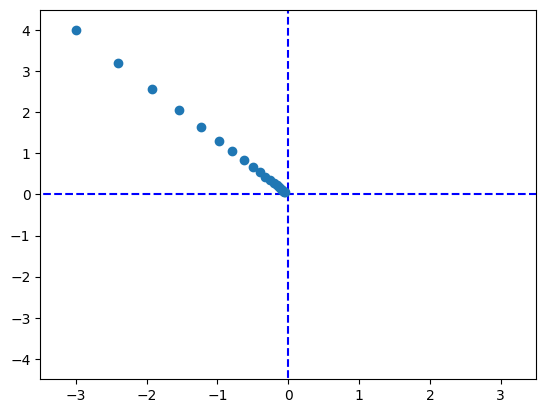

In [69]:
def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x
    x_history = []
    for i in range(step_num):
        x_history.append(x.copy())
        grad = numerical_gradient(f, x)
        x -= lr * grad
    return x, np.array(x_history)

init_x = np.array([-3.0, 4.0])

lr = 0.1
step_num = 20
x, x_history = gradient_descent(function_2, init_x=init_x, lr=lr, step_num=step_num)

plt.plot([-5, 5], [0, 0], '--b')
plt.plot([0, 0], [-5, 5], '--b')
plt.plot(x_history[:, 0], x_history[:, 1], 'o')

plt.xlim(-3.5, 3.5)
plt.ylim(-4.5, 4.5)
plt.show()

In [70]:
def gradient_descent(f, init_x, lr, step_num=100):
    x = init_x
    for i in range(step_num):
        grad = numerical_gradient(f, x)
        x -= lr * grad
    return x

In [71]:
lr = 10.0
gradient_descent(function_2, init_x, lr, step_num=100)

array([ 3.98264457e+12, -6.43085837e+12])

In [72]:
lr = 1e-10
init_x = np.array([-3.0,4.0])
gradient_descent(function_2, init_x, lr, step_num=100)

array([-2.99999994,  3.99999992])

In [73]:
def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T
    x = x - np.max(x)
    return np.exp(x) / np.sum(np.exp(x))

def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
    if t.size == y.size:
        t = t.argmax(axis=1) # t = [2, 3, 7, 8, 4, ...]
    batch_size = y.shape[0] # batch_size = 1, batch_size = 100
    return -np.sum(np.log(y[np.arange(batch_size), t])) / batch_size

def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x)

    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x) # f(x+h)

        x[idx] = tmp_val - h
        fxh2 = f(x) # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)

        x[idx] = tmp_val
        it.iternext()
    return grad

In [74]:
class simpleNet:
    def __init__(self):
        self.W = np.random.randn(2, 3)

    def predict(self, x):
        return np.dot(x, self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)
        return loss

In [75]:
net = simpleNet()
print(net.W)

[[ 1.14710659 -0.45269654  0.39779965]
 [-0.47040217 -2.12224369 -1.51127751]]


In [76]:
x = np.array([0.6, 0.9])

In [77]:
p = net.predict(x)
print(p)

[ 0.26490201 -2.18163724 -1.12146997]


In [78]:
np.argmax(p)

np.int64(0)

In [79]:
t = np.array([1, 0,])
net.loss(x ,t)

np.float64(3.0267575121437145)

net.W, loss(x, t)가 있을 때 dw 값을 구해보자

In [80]:
# 내가 한거 틀림
net.loss(x, t) / net.W

array([[ 2.63860179, -6.68606279,  7.60874846],
       [-6.43440385, -1.42620639, -2.00278075]])

In [81]:
# 강사님 버전
# numerical_gradient 기울기 구하는함수 사용
dW = numerical_gradient(net.loss(x, t), net.W) # => 이런식으로 하면 에러

TypeError: 'numpy.float64' object is not callable

In [82]:
def f(W):
    return net.loss(x, t)

In [83]:
# net.loss(x ,t)를 먼저 해버리면 값이 되버려서 x를 기울기 구하는 함수 들어갈 때 실행
dW = numerical_gradient(f, net.W)
dW

array([[ 0.29783186, -0.52225894,  0.22442708],
       [ 0.44674779, -0.78338841,  0.33664062]])

In [84]:
# 이런 방식도 있음
f = lambda w : net.loss(x, t)
dW = numerical_gradient(f, net.W)
dW

array([[ 0.29783186, -0.52225894,  0.22442708],
       [ 0.44674779, -0.78338841,  0.33664062]])

\begin{equation*}
W =  \begin{vmatrix}
w_{11} w_{21} w_{31}\\
w_{12} w_{22} w_{32}\
\end{vmatrix}
\end{equation*}
\begin{equation*}
\frac{\partial{L}}{\partial{W}} =  \begin{vmatrix}
\frac{\partial{L}}{\partial{W_{11}}} \frac{\partial{L}}{\partial{W_{21}}} \frac{\partial{L}}{\partial{W_{31}}}\\
\frac{\partial{L}}{\partial{W_{12}}} \frac{\partial{L}}{\partial{W_{22}}} \frac{\partial{L}}{\partial{W_{32}}}\
\end{vmatrix}
\end{equation*}

# 4. 신경망 학습

In [85]:
def sigmoid(x):
    return expit(x)

In [86]:
def sigmoid_grad(x):
    return (1.0 - sigmoid(x)) * sigmoid(x)

In [87]:
def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T
    x = x - np.max(x)
    return np.exp(x) / np.sum(np.exp(x))

2층 신경망, 데이터 : 손글씨 숫자(MNIST 데이터 사용)

In [88]:
class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01): # 가중치를 weight_init_std 표준편차로 주겠다.
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)
        return y

    def loss(self, x, t):
        y = self.predict(x)
        return cross_entropy_error(y, t)

    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])
        return grads

    def gradient(self, x, t):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}

        batch_num = x.shape[0]

        # forward
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        #backward
        dy = (y-t) / batch_num
        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)

        da1 = np.dot(dy, W2.T)
        dz1 = sigmoid_grad(a1) * da1
        grads['W1'] = np.dot(x.T, dz1)
        grads['b1'] = np.sum(dz1, axis=0)
        return grads

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)
        accuracy_ = np.sum(y == t) / float(x.shape[0])
        return accuracy_

In [89]:
x_train.shape, t_train.shape, x_test.shape, t_test.shape

((60000, 784), (60000, 10), (10000, 784), (10000, 10))

In [94]:
network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

iter_num = 10000
train_size = x_train.shape[0]
learning_rate = 0.1
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1) # 한 레포크당 반복 횟수

for i in range(iter_num):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # grad = network.numerical_gradient(x_batch, t_batch) # 784번 해야해서 엄청 기다려야함 4시간 정도 예상
    grad = network.gradient(x_batch, t_batch) # 4시간 돌리긴 힘드니 shape 단축, 검사용

    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print(f'train acc : {train_acc}')
        print(f'test acc : {test_acc}')

train acc : 0.09751666666666667
test acc : 0.0974
train acc : 0.78375
test acc : 0.7887
train acc : 0.8778666666666667
test acc : 0.8812
train acc : 0.8977
test acc : 0.9009
train acc : 0.9061
test acc : 0.9096
train acc : 0.9136166666666666
test acc : 0.9162
train acc : 0.9193333333333333
test acc : 0.9206
train acc : 0.9241333333333334
test acc : 0.9259
train acc : 0.9278833333333333
test acc : 0.9301
train acc : 0.9306666666666666
test acc : 0.9336
train acc : 0.9336833333333333
test acc : 0.9359
train acc : 0.9359666666666666
test acc : 0.939
train acc : 0.9391666666666667
test acc : 0.94
train acc : 0.9410833333333334
test acc : 0.9411
train acc : 0.9427
test acc : 0.942
train acc : 0.945
test acc : 0.9437
train acc : 0.9468166666666666
test acc : 0.946


(0.0, 3.0)

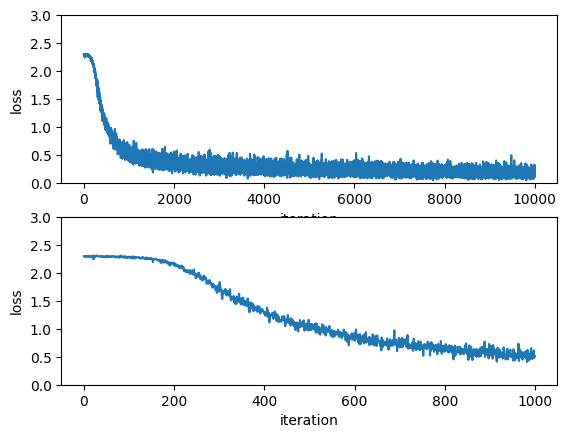

In [91]:
f, (ax1, ax2) = plt.subplots(2, 1)
x = np.array(range(iter_num))
ax1.plot(x, train_loss_list, label='loss')
ax1.set_xlabel("iteration")
ax1.set_ylabel("loss")
ax1.set_ylim(0, 3.0)
ax2.plot(x[:1000], train_loss_list[:1000], label='loss')
ax2.set_xlabel("iteration")
ax2.set_ylabel("loss")
ax2.set_ylim(0, 3.0)

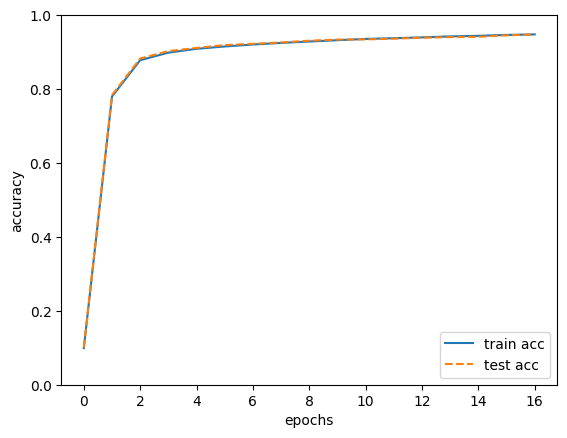

In [92]:
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

In [92]:
nwt_grads = TwoLayerNet(784, 50, 10)
x_batch = x_train[:4]
t_batch = t_train[:4]

In [ ]:
grad_numerical = nwt_grads.numerical_gradient(x_batch, t_batch)
grad_back = nwt_grads.gradient(x_batch, t_batch)

In [ ]:
for key in grad_numerical.keys():
    diff = np.average(np.abs(grad_back[key] - grad_numerical[key]))
    print(diff)

# 오차역전파

계산 그래프 : 계산과정을 그래프로 나타낸것
```
노드와 엣지로 표현
노드에는 연산자, 엣지에는 값을 사용
```

계산 그래프 사용
```
1. 계산그래프를 그린다.
2. 그래프에서 계산을 왼쪽에서 오른쪽으로 수행한다.
```